Project Scenario

You have been employed as a Data Scientist by a consultancy firm. The firm has a client who is a used car dealer. They have a special feature on Ford cars and they want your firm to design a model that can predict the optimum quotation price for the cars in their lot. They provide you with sales data for the past few years. The dataset contains different features of the cars and the price they were sold at.

The tasks assigned to you are as follows.

    There might be a few duplicate entries and a few missing values in the dataset. Data cleaning will be a part of the assignment.
    You have to perform exploratory data analysis to draw keen insights on the data and determine the effect of different features on the price. Some specific requests by the client include: a. Identify number of sales for each fuel type b. Identify which transmission type has more price outliers
    Compare the models with linear, polynomial and ridge regressions on single and multiple variables to find the best performing model
    Perform a Grid Search on the Ridge regression model to identify the optimum hyperparameter for the model for best performance.


In [3]:
import pandas as pd

In [9]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0271EN-SkillsNetwork/labs/v1/m3/data/used_car_price_analysis.csv"
df = pd.read_csv(URL)
df.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
0,Fiesta,2017,Automatic,15944,Petrol,150.0,57.7,1.0,12000
1,Focus,2018,Manual,9083,Petrol,150.0,57.7,1.0,14000
2,Focus,2017,Manual,12456,Petrol,150.0,57.7,1.0,13000
3,Fiesta,2019,Manual,10460,Petrol,145.0,40.3,1.5,17500
4,Fiesta,2019,Automatic,1482,Petrol,145.0,48.7,1.0,16500


In [15]:
print("Missing values before filling:")
print(df.isnull().sum())

# Fill numerical columns with their mean
for col in df.select_dtypes(include=['number']).columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

print("\nMissing values after filling:")
print(df.isnull().sum())

Missing values before filling:
model           0
year            0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
price           0
dtype: int64

Missing values after filling:
model           0
year            0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
price           0
dtype: int64


### Dropping Duplicate Entries
Let's ensure data uniqueness by identifying and removing any duplicate rows from the DataFrame.

In [18]:
initial_rows = df.shape[0]
print(f"Number of rows before dropping duplicates: {initial_rows}")

df.drop_duplicates(inplace=True)

rows_after_duplicates = df.shape[0]
print(f"Number of rows after dropping duplicates: {rows_after_duplicates}")
print(f"Number of duplicate rows removed: {initial_rows - rows_after_duplicates}")

Number of rows before dropping duplicates: 17812
Number of rows after dropping duplicates: 17812
Number of duplicate rows removed: 0


To confirm the changes, let's display the first few rows of the DataFrame and its information after removing duplicates.

In [19]:
display(df.head())
print(df.info())

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
0,Fiesta,2017,Automatic,15944,Petrol,150.0,57.7,1.0,12000
1,Focus,2018,Manual,9083,Petrol,150.0,57.7,1.0,14000
2,Focus,2017,Manual,12456,Petrol,150.0,57.7,1.0,13000
3,Fiesta,2019,Manual,10460,Petrol,145.0,40.3,1.5,17500
4,Fiesta,2019,Automatic,1482,Petrol,145.0,48.7,1.0,16500


<class 'pandas.core.frame.DataFrame'>
Index: 17812 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17812 non-null  object 
 1   year          17812 non-null  int64  
 2   transmission  17812 non-null  object 
 3   mileage       17812 non-null  int64  
 4   fuelType      17812 non-null  object 
 5   tax           17812 non-null  float64
 6   mpg           17812 non-null  float64
 7   engineSize    17812 non-null  float64
 8   price         17812 non-null  int64  
dtypes: float64(3), int64(3), object(3)
memory usage: 1.4+ MB
None


In [20]:
correlation_matrix = df.select_dtypes(include=['number']).corr()
price_correlations = correlation_matrix['price'].sort_values(ascending=False)
top_5_correlated = price_correlations[1:6] # Exclude 'price' itself and take the next 5

print("Top 5 attributes with the biggest correlation with 'price':")
print(top_5_correlated)

Top 5 attributes with the biggest correlation with 'price':
year          0.635715
engineSize    0.411451
tax           0.405970
mpg          -0.346263
mileage      -0.530483
Name: price, dtype: float64


In [21]:
fuel_type_counts = df['fuelType'].value_counts()
print("Number of cars for each fuel type:")
print(fuel_type_counts)

Number of cars for each fuel type:
fuelType
Petrol      12081
Diesel       5706
Hybrid         22
Electric        2
Other           1
Name: count, dtype: int64


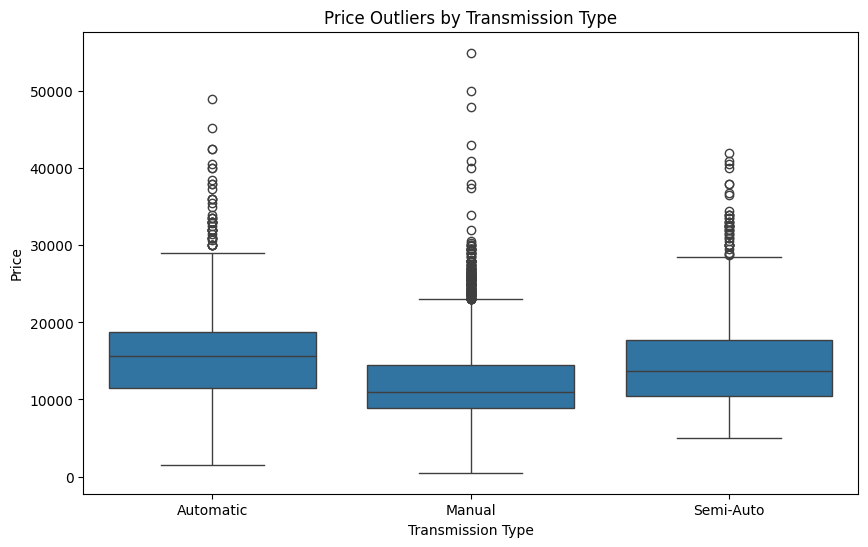

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='transmission', y='price', data=df)
plt.title('Price Outliers by Transmission Type')
plt.xlabel('Transmission Type')
plt.ylabel('Price')
plt.show()

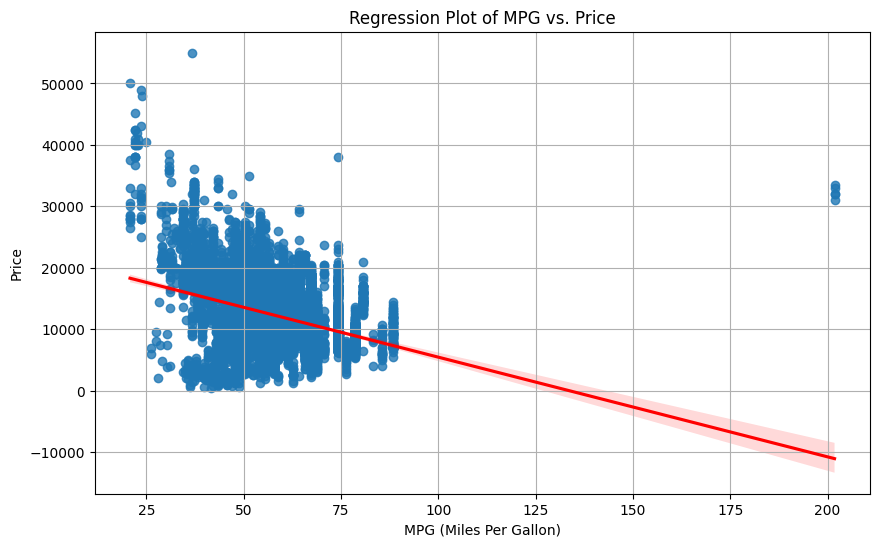

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.regplot(x='mpg', y='price', data=df, line_kws={'color': 'red'})
plt.title('Regression Plot of MPG vs. Price')
plt.xlabel('MPG (Miles Per Gallon)')
plt.ylabel('Price')
plt.grid(True)
plt.show()

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define the source (independent) and target (dependent) variables
X = df[['mpg']]  # Source variable (features)
y = df['price']    # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Linear Regression model
linear_model = LinearRegression()

# Train the model using the training data
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = linear_model.predict(X_test)

# Calculate R-squared value
r2 = r2_score(y_test, y_pred)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

print(f"Linear Regression Model for Price vs. MPG:")
print(f"  R-squared (R^2): {r2:.4f}")
print(f"  Mean Squared Error (MSE): {mse:.2f}")

Linear Regression Model for Price vs. MPG:
  R-squared (R^2): 0.1325
  Mean Squared Error (MSE): 19441984.66


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define the source (independent) and target (dependent) variables
X_multi = df[['year', 'engineSize', 'tax', 'mpg', 'mileage']]  # Multiple source variables
y_multi = df['price']    # Target variable

# Split the data into training and testing sets
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

# Create a Linear Regression model
linear_model_multi = LinearRegression()

# Train the model using the training data
linear_model_multi.fit(X_train_multi, y_train_multi)

# Make predictions on the test set
y_pred_multi = linear_model_multi.predict(X_test_multi)

# Calculate R-squared value
r2_multi = r2_score(y_test_multi, y_pred_multi)

# Calculate Mean Squared Error
mse_multi = mean_squared_error(y_test_multi, y_pred_multi)

print(f"Linear Regression Model for Price vs. Multiple Variables:")
print(f"  R-squared (R^2): {r2_multi:.4f}")
print(f"  Mean Squared Error (MSE): {mse_multi:.2f}")

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [40]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define the source (independent) and target (dependent) variables
X_poly = df[['year', 'engineSize', 'tax', 'mpg', 'mileage']]  # Source variables
y_poly = df['price']    # Target variable

# Split the data into training and testing sets
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y_poly, test_size=0.2, random_state=42)

# Create a pipeline with StandardScaler, PolynomialFeatures (degree 2), and LinearRegression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly_features', PolynomialFeatures(degree=2)),
    ('linear_regressor', LinearRegression())
])

# Fit the pipeline to the training data
pipeline.fit(X_train_poly, y_train_poly)

# Make predictions on the test set
y_pred_poly = pipeline.predict(X_test_poly)

# Calculate R-squared value
r2_poly = r2_score(y_test_poly, y_pred_poly)

# Calculate Mean Squared Error
mse_poly = mean_squared_error(y_test_poly, y_pred_poly)

print(f"Pipeline Model with Polynomial Features (Degree 2):")
print(f"  R-squared (R^2): {r2_poly:.4f}")
print(f"  Mean Squared Error (MSE): {mse_poly:.2f}")

ValueError: Input X contains NaN.
PolynomialFeatures does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [41]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Reusing the split data from the multi-variable linear regression step
X_train_ridge = X_train_multi
X_test_ridge = X_test_multi
y_train_ridge = y_train_multi
y_test_ridge = y_test_multi

# Create a Ridge Regression model with alpha = 0.1
ridge_model = Ridge(alpha=0.1)

# Train the model using the training data
ridge_model.fit(X_train_ridge, y_train_ridge)

# Make predictions on the test set
y_pred_ridge = ridge_model.predict(X_test_ridge)

# Calculate R-squared value
r2_ridge = r2_score(y_test_ridge, y_pred_ridge)

# Calculate Mean Squared Error
mse_ridge = mean_squared_error(y_test_ridge, y_pred_ridge)

print(f"Ridge Regression Model (alpha=0.1):")
print(f"  R-squared (R^2): {r2_ridge:.4f}")
print(f"  Mean Squared Error (MSE): {mse_ridge:.2f}")

ValueError: Input X contains NaN.
Ridge does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Load your DataFrame (replace with your actual data loading method)
# df = pd.read_csv('your_data.csv')

# Assuming df is your DataFrame
# Define source attributes and target attribute
source_attributes = ['year', 'mileage', 'tax', 'mpg', 'engineSize']  # Adjust as necessary
target_attribute = 'price'

# Split the data into training and testing sets (80% train, 20% test)
X = df[source_attributes]
y = df[target_attribute]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Construct and fit the Ridge regression model
ridge_model = Ridge(alpha=0.1)  # Set regularization parameter to 0.1
ridge_model.fit(X_train, y_train)

# Predict using the test data
y_pred = ridge_model.predict(X_test)

# Calculate MSE and R² values
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the results
print(f'R²: {r2}')
print(f'Mean Squared Error (MSE): {mse}')

R²: 0.6917134446113233
Mean Squared Error (MSE): 6912725.801054711


In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Assuming df is your DataFrame and the target variable is 'target'
# Replace 'target' with the actual name of your target column
# Replace the source attribute names in source_attributes with your actual column names
source_attributes = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
target = 'price'  # Replace with your actual target variable name

# 1. Split the data into training and testing sets (80% training, 20% testing)
X = df[source_attributes]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Apply second-degree polynomial transformation
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 3. Construct and fit a Ridge regression model
ridge_model = Ridge(alpha=0.1)  # Regularization parameter set to 0.1
ridge_model.fit(X_train_poly, y_train)

# 4. Compute the MSE and R² values for the Ridge regression model
y_pred = ridge_model.predict(X_test_poly)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Output the results
print(f'Mean Squared Error (MSE): {mse}')
print(f'R²: {r2}')

Mean Squared Error (MSE): 7326174.879821923
R²: 0.6732748726224969


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.17676e-24): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [42]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import numpy as np

# Step 1: Split the data into training and testing sets
source_attributes = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
target_attribute = 'price'

X = df[source_attributes]
y = df[target_attribute]

# Explicitly drop rows with any NaN values from X and y as a safeguard
# This addresses the ValueError: Input X contains NaN
initial_rows = X.shape[0]
combined_df = pd.concat([X, y], axis=1).dropna()
X = combined_df[source_attributes]
y = combined_df[target_attribute]
if X.shape[0] < initial_rows:
    print(f"Warning: {initial_rows - X.shape[0]} rows dropped due to NaN values before splitting.")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2 & 3: Apply second-degree polynomial transformation and Perform Grid Search on Ridge regression
# Using a pipeline to include StandardScaler before PolynomialFeatures for numerical stability
# and to ensure proper data preprocessing within GridSearchCV
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('ridge', Ridge())
])

# Define the parameter grid for alpha (using 'ridge__alpha' for pipeline)
param_grid = {
    'ridge__alpha': np.logspace(-4, 4, 10) # Using a wider range for alpha values
}

grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=4, scoring='r2', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train) # Fit the pipeline with X_train

# Get the best model
best_model = grid_search.best_estimator_

# Step 4: Calculate MSE and R² values for the Ridge Regression model
y_pred = best_model.predict(X_test) # Predict using X_test, pipeline handles transformations

mse = mean_squared_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)

# Output the results
print("Best Alpha:", best_model.named_steps['ridge'].alpha) # Access alpha from the best_model in pipeline
print("Mean Squared Error (MSE):", mse)
print("R²:", r_squared)


Fitting 4 folds for each of 10 candidates, totalling 40 fits
Best Alpha: 1291.5496650148827
Mean Squared Error (MSE): 5717046.910207269
R²: 0.7478063974412834
